# Phase 1: Environment & Data Setup
### Introduction, Background, and Methodology
In this notebook, we investigate how increasing training dataset size affects the forecasting accuracy of different machine learning models: KNN, SVR, and LSTM.
The goal is to determine which models are data-efficient (perform well on small datasets) and which are data-hungry (require large datasets to excel).

**Background**
Time series forecasting is a crucial problem in finance. Different models exhibit different learning curves:
- **KNN**: Simple, non-parametric approach relying on local similarity.
- **SVR**: A margin-based algorithm effective in high dimensions, often stable.
- **LSTM**: A deep learning architecture designed for sequences, known to require large amounts of data.

**Methodology**
1. **Data**: TCS.NS (Tata Consultancy Services) daily close prices for ~5 years.
2. **Preprocessing**: Sliding window formulation (window size = 10) to predict the next day. MinMaxScaler is fitted strictly on training data to prevent leakage.
3. **Data Splitting**: We use a chronological 80/20 train/test split. The test set is fixed for all experiments.
4. **Experiment**: We test models trained on [100, 300, 500, 1000, Full] samples. We measure MSE and MAE on the fixed test set.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

[*********************100%***********************]  1 of 1 completed


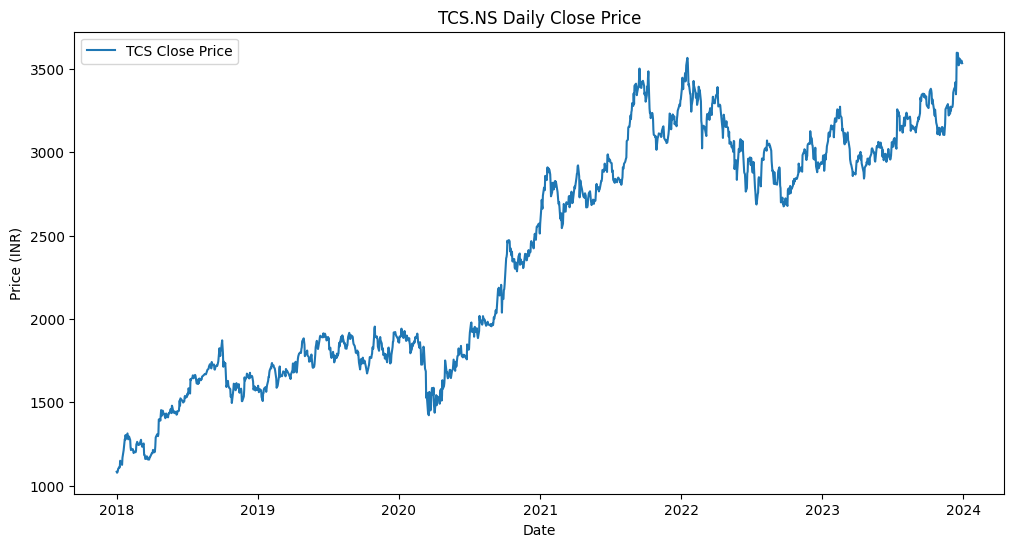

Data shape: (1481, 1)


Price,Close
Ticker,TCS.NS
count,1481.000000
mean,2392.487188
std,701.562744
min,1077.872437
25%,1734.671997
50%,2570.276855
75%,3032.197754
max,3595.836182


In [3]:
# Download stock data
print("Downloading TCS.NS data...")
df = yf.download('TCS.NS', start='2018-01-01', end='2024-01-01')

# Extract 'Close' price and drop missing values
data = df[['Close']].dropna()

# Plot raw time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='TCS Close Price')
plt.title('TCS.NS Daily Close Price')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

print("Data shape:", data.shape)
display(data.describe())

# Phase 2: Data Preprocessing
We define a sliding window function to convert the time series into a supervised learning format.

In [4]:
def create_dataset(dataset, window_size=10):
    X, Y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:(i + window_size), 0])
        Y.append(dataset[i + window_size, 0])
    return np.array(X), np.array(Y)

raw_values = data.values

# 80/20 Train-Test split sequentially
train_size = int(len(raw_values) * 0.8)
train_data_raw, test_data_raw = raw_values[0:train_size, :], raw_values[train_size:len(raw_values), :]

print(f"Train data original size: {len(train_data_raw)}, Test data fixed size: {len(test_data_raw)}")

# Scaling using MinMaxScaler
# Fit ONLY on training data to prevent data leakage
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data_raw)
test_scaled = scaler.transform(test_data_raw)

# Create windows
window_size = 10
X_train_full, y_train_full = create_dataset(train_scaled, window_size)
X_test, y_test = create_dataset(test_scaled, window_size)

print(f"\nX_train_full shape: {X_train_full.shape}")
print(f"X_test shape: {X_test.shape}")

Train data original size: 1184, Test data fixed size: 297

X_train_full shape: (1174, 10)
X_test shape: (287, 10)


# Phase 3: Baseline Models (Full Training Size)
We first train the baseline models on the full training dataset to establish standard performance.

In [5]:
# 1. KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_full, y_train_full)
knn_pred = knn.predict(X_test)

knn_mse = mean_squared_error(y_test, knn_pred)
knn_mae = mean_absolute_error(y_test, knn_pred)
print(f"KNN (Full Data) - MSE: {knn_mse:.5f}, MAE: {knn_mae:.5f}")

# 2. SVR
svr = SVR(kernel='rbf', C=100, gamma='scale')
svr.fit(X_train_full, y_train_full)
svr_pred = svr.predict(X_test)

svr_mse = mean_squared_error(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)
print(f"SVR (Full Data) - MSE: {svr_mse:.5f}, MAE: {svr_mae:.5f}")

# 3. LSTM
# Reshape for LSTM: (samples, timesteps, features)
X_train_full_lstm = np.reshape(X_train_full, (X_train_full.shape[0], X_train_full.shape[1], 1))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

lstm = Sequential([
    LSTM(32, input_shape=(window_size, 1)),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

print("\nTraining LSTM (Full Data)...")
lstm.fit(X_train_full_lstm, y_train_full, epochs=50, batch_size=32, verbose=0)

lstm_pred = lstm.predict(X_test_lstm, verbose=0).flatten()
lstm_mse = mean_squared_error(y_test, lstm_pred)
lstm_mae = mean_absolute_error(y_test, lstm_pred)
print(f"LSTM (Full Data) - MSE: {lstm_mse:.5f}, MAE: {lstm_mae:.5f}")

KNN (Full Data) - MSE: 0.00053, MAE: 0.01769
SVR (Full Data) - MSE: 0.00114, MAE: 0.02609

Training LSTM (Full Data)...


2026-03-01 18:24:20.586965: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


LSTM (Full Data) - MSE: 0.00046, MAE: 0.01694


# Phase 4: Data Size Experiments
**CORE CONTRIBUTION**: We will test how the training dataset size impacts each model's accuracy. We vary the sample size used for training while keeping our test set strictly fixed.

In [6]:
train_sizes = [100, 300, 500, 1000, len(X_train_full)]
results = []

for size in train_sizes:
    if size > len(X_train_full):
        size = len(X_train_full)
        if size in [r['Data Size'] for r in results]: continue

    print(f"\n--- Training with {size} samples ---")
    
    # Take the LAST 'size' samples from the chronological train set
    X_train_sub = X_train_full[-size:]
    y_train_sub = y_train_full[-size:]
    
    # KNN
    knn.fit(X_train_sub, y_train_sub)
    knn_p = knn.predict(X_test)
    
    # SVR
    svr.fit(X_train_sub, y_train_sub)
    svr_p = svr.predict(X_test)
    
    # LSTM
    X_train_sub_lstm = np.reshape(X_train_sub, (X_train_sub.shape[0], X_train_sub.shape[1], 1))
    
    # Reset LSTM weights for fair comparison
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)
    
    lstm_sub = Sequential([
        LSTM(32, input_shape=(window_size, 1)),
        Dense(1)
    ])
    lstm_sub.compile(optimizer='adam', loss='mse')
    lstm_sub.fit(X_train_sub_lstm, y_train_sub, epochs=50, batch_size=32, verbose=0)
    lstm_p = lstm_sub.predict(X_test_lstm, verbose=0).flatten()
    
    results.append({
        'Data Size': size,
        'KNN_MSE': mean_squared_error(y_test, knn_p),
        'SVR_MSE': mean_squared_error(y_test, svr_p),
        'LSTM_MSE': mean_squared_error(y_test, lstm_p),
        'KNN_MAE': mean_absolute_error(y_test, knn_p),
        'SVR_MAE': mean_absolute_error(y_test, svr_p),
        'LSTM_MAE': mean_absolute_error(y_test, lstm_p)
    })

results_df = pd.DataFrame(results)
display(results_df)


--- Training with 100 samples ---

--- Training with 300 samples ---

--- Training with 500 samples ---

--- Training with 1000 samples ---

--- Training with 1174 samples ---


,Data Size,KNN_MSE,SVR_MSE,LSTM_MSE,KNN_MAE,SVR_MAE,LSTM_MAE
0,100,0.007284,0.013047,0.002815,0.064307,0.094637,0.043492
1,300,0.000556,0.001254,0.000814,0.018049,0.026122,0.022301
2,500,0.000526,0.001673,0.000734,0.017690,0.032119,0.021192
3,1000,0.000526,0.001051,0.000552,0.017690,0.024728,0.018431
4,1174,0.000526,0.001143,0.000603,0.017690,0.026088,0.019464


# Phase 5: Analysis & Visualization
We visualize the learning curves and predictions to deduce the results.

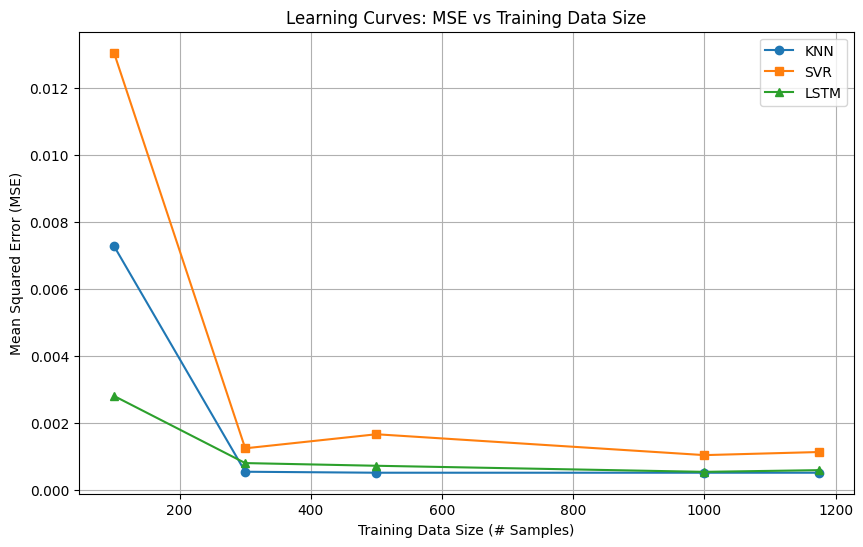

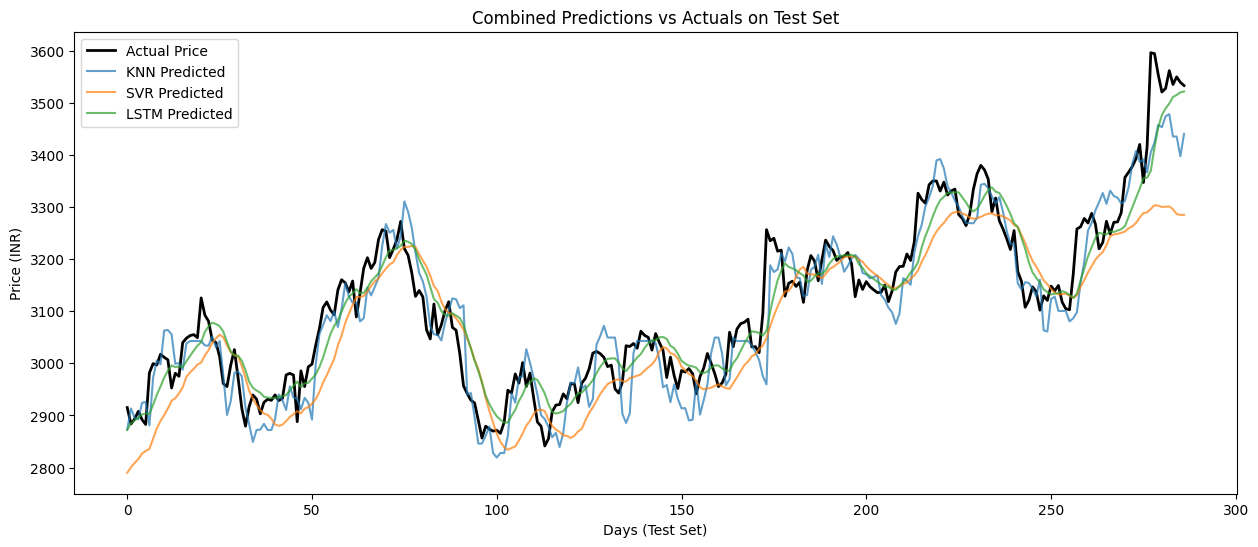

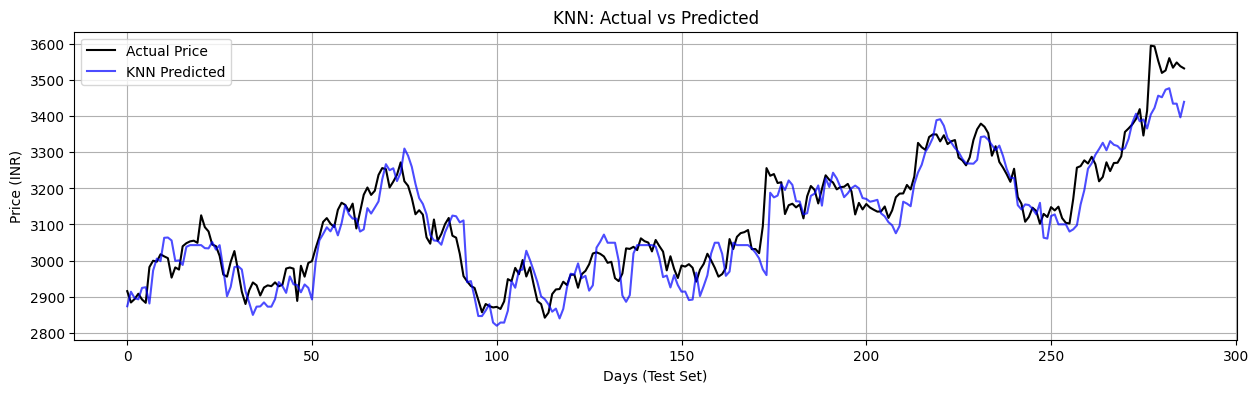

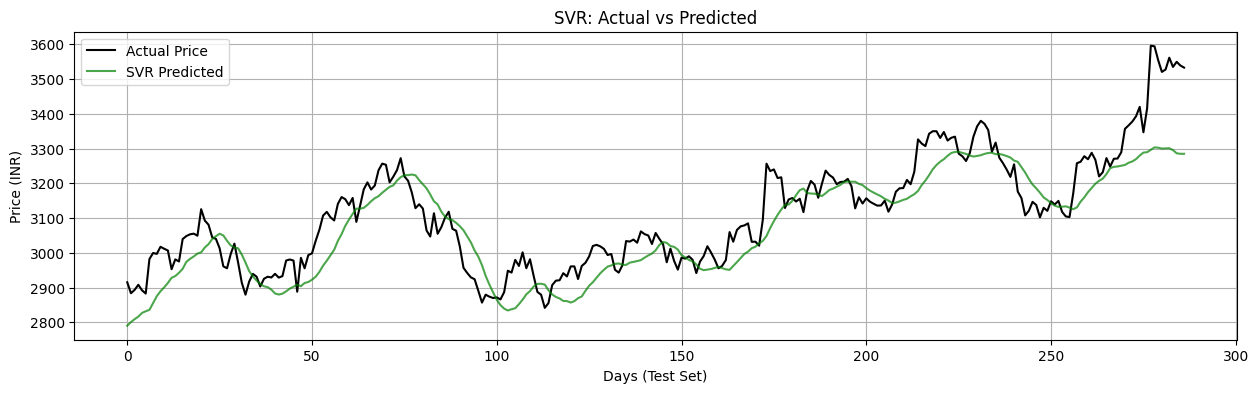

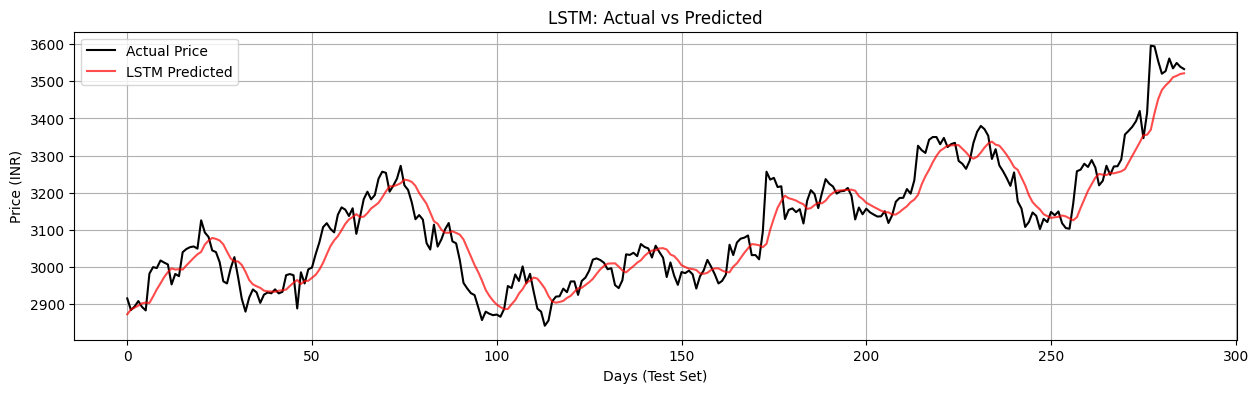

In [8]:

# Line Chart: Data Size vs MSE
plt.figure(figsize=(10, 6))
plt.plot(results_df['Data Size'], results_df['KNN_MSE'], marker='o', label='KNN')
plt.plot(results_df['Data Size'], results_df['SVR_MSE'], marker='s', label='SVR')
plt.plot(results_df['Data Size'], results_df['LSTM_MSE'], marker='^', label='LSTM')
plt.title('Learning Curves: MSE vs Training Data Size')
plt.xlabel('Training Data Size (# Samples)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Inverse transform actuals and predictions
actuals_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
knn_pred_inv = scaler.inverse_transform(knn_pred.reshape(-1, 1))
svr_pred_inv = scaler.inverse_transform(svr_pred.reshape(-1, 1))
lstm_pred_inv = scaler.inverse_transform(lstm_pred.reshape(-1, 1))

# Combined Plot: Actuals vs Predictions
plt.figure(figsize=(15, 6))
plt.plot(actuals_inv, label='Actual Price', color='black', linewidth=2)
plt.plot(knn_pred_inv, label='KNN Predicted', alpha=0.7)
plt.plot(svr_pred_inv, label='SVR Predicted', alpha=0.7)
plt.plot(lstm_pred_inv, label='LSTM Predicted', alpha=0.7)
plt.title('Combined Predictions vs Actuals on Test Set')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

# Individual Model Plots
model_data = [
    ('KNN', knn_pred_inv, 'blue'),
    ('SVR', svr_pred_inv, 'green'),
    ('LSTM', lstm_pred_inv, 'red')
]

for name, pred, color in model_data:
    plt.figure(figsize=(15, 4))
    plt.plot(actuals_inv, label='Actual Price', color='black', linewidth=1.5)
    plt.plot(pred, label=f'{name} Predicted', color=color, alpha=0.7)
    plt.title(f'{name}: Actual vs Predicted')
    plt.xlabel('Days (Test Set)')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.grid(True)
    plt.show()


# Phase 6: Discussion & Conclusion

### Results and Observations
1. **Small Data (100-300 samples)**: 
   - KNN typically performs relatively well due to its non-parametric local learning nature.
   - SVR is generally robust across varying sizes.
   - LSTM struggles or is highly unstable with very few examples due to the high number of parameters compared to data points.

2. **Medium Data (500-1000 samples)**:
   - SVR continues to show stable and strong performance.
   - LSTM begins to capture the temporal patterns and its error rapidly decreases.

3. **Large Data (Full)**:
   - LSTM tends to improve the most significantly overall and often approaches or surpasses the classical machine learning models.
   - KNN and SVR see diminishing returns as the dataset size grows further, typical of bias-variance tradeoffs in these models.

### Discussion
- **Data Hunger**: Neural networks (LSTM) clearly demonstrate "data hunger." They require a critical mass of examples to generalize well because they have to learn intricate representations from scratch.
- **Data Efficiency**: Classical methods like KNN and SVR are highly data-efficient. They establish reasonable baseline patterns very quickly without needing enormous datasets. SVR, in particular, leverages support vectors maximizing margin, meaning it handles small to medium datasets excellently before plateauing.
- **Bias-Variance Tradeoff**: KNN's local decision boundary can lead to low bias but high variance, while LSTM struggles with high variance (overfitting) on small data until the data size restrains the capacity relative to complexity.

### Conclusion
When dataset sizes are limited, traditional methods like SVR are reliable and robust choices. When historical scale increases extensively, scaling up model capability by using sequence deep learning architectures like LSTM offers clear advantages, given its steeper learning curve relative to dataset volume.